In [ ]:
#code to create unique occupied states plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

In [ ]:
# [trained_on]_[data_from]
top_qcd = pd.read_csv("../output/plot_data/probs_50_epochs/top_qcd.csv")
top_top = pd.read_csv("../output/plot_data/probs_50_epochs/top_top.csv")
qcd_qcd = pd.read_csv("../output/plot_data/probs_50_epochs/qcd_qcd.csv")
qcd_top = pd.read_csv("../output/plot_data/probs_50_epochs/qcd_top.csv")


In [ ]:
#df_untrained = pd.read_csv("../output/plot_data/untrained_probs_ttbar.csv")

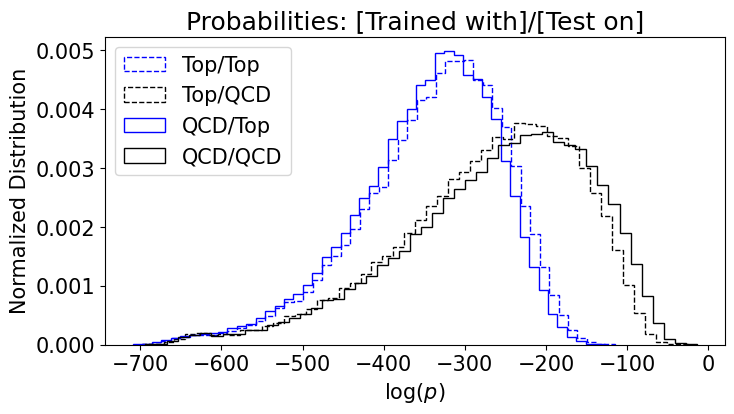

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

bins = 30

# normalized histogram (area = 1), step style
ax.hist(
    top_top["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.0,
    linestyle="--",
    color="blue",
    label="Top/Top"
)

ax.hist(
    top_qcd["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.0,
    linestyle="--",
    color="black",
    label="Top/QCD"
)

ax.hist(
    qcd_top["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.0,
    color="blue",
    label="QCD/Top"
)

ax.hist(
    qcd_qcd["probs"],
    bins=bins,                 # adjust for smoothness
    density=True,            # normalization
    histtype="step",
    linewidth=1.0,
    color="black",
    label="QCD/QCD"
)


ax.set_ylabel("Normalized Distribution")
ax.set_xlabel(r"$\log(p)$")

ax.set_title("Probabilities: [Trained with]/[Test on]")

ax.legend()

plt.show()

In [ ]:
top_top_probs = top_top["probs"].values
top_top_mult = top_top["multiplicity"].values

values_top_top = np.stack([top_top["probs"], top_top["multiplicity"]])

kde_top_top = gaussian_kde(values_top_top)

xmin, xmax = top_top_probs.min(), top_top_probs.max()
ymin, ymax = top_top_mult.min(), top_top_mult.max()

xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
f = np.reshape(kde_top_top(positions).T, xx.shape)

In [ ]:
# Sort density values
f_flat = f.flatten()
idx = np.argsort(f_flat)[::-1]
f_sorted = f_flat[idx]
cdf = np.cumsum(f_sorted)
cdf /= cdf[-1]

# Find density thresholds
levels = []
for frac in [0.25, 0.50, 0.75]:
    levels.append(f_sorted[np.searchsorted(cdf, frac)])

levels = sorted(levels)

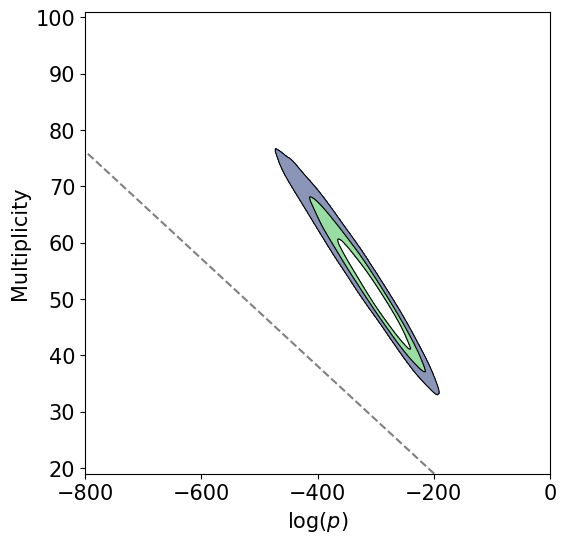

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))

# Contours
ax.contourf(xx, yy, f, levels=levels, alpha=0.6)

# Optional contour lines
ax.contour(xx, yy, f, levels=levels, colors="k", linewidths=0.8)

ax.set_xlabel(r'$\log(p)$')
ax.set_ylabel("Multiplicity")

Nd = 40*30*30  # example
n_line = np.linspace(ymin, ymax, 200)
logp_line = np.log(1/Nd) * n_line

ax.set_xlim(-800,0)

ax.plot(logp_line, n_line, '--', color='gray')

plt.show()

In [ ]:
plt.rcParams['font.size'] = 15

log_p = top_top["probs"]
counts = top_top["multiplicity"]
values = np.vstack([log_p,counts])

kde = gaussian_kde(values)

# Grid für Dichte
xmin, xmax = -1200, 0
ymin, ymax = 0, 105
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
grid_coords = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(grid_coords).reshape(xx.shape)

# Dichte-Quantile (75%, 50%, 25%)
z_sorted = np.sort(zz.ravel())[::-1]
z_cumsum = np.cumsum(z_sorted)
z_cumsum /= z_cumsum[-1]

levels = [
    z_sorted[np.searchsorted(z_cumsum, 0.75)],
    z_sorted[np.searchsorted(z_cumsum, 0.50)],
    z_sorted[np.searchsorted(z_cumsum, 0.25)],
]

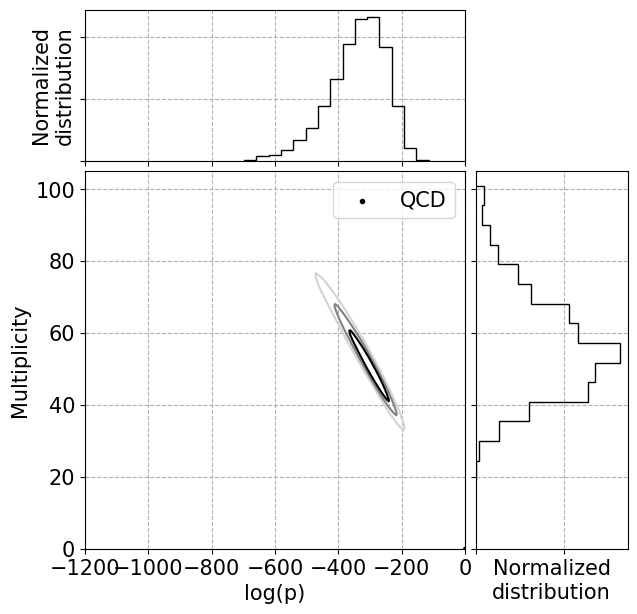

In [ ]:
fig = plt.figure(figsize=(7,7), dpi=100)
gs = GridSpec(
    2, 2,
    width_ratios=[2.5, 1],
    height_ratios=[1, 2.5],
    hspace=0.04,
    wspace=0.04
)

bins=15

# Achsen definieren
ax_histx = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[1, 0])
ax_histy = fig.add_subplot(gs[1, 1])


contours = ax_main.contour(xx, yy, zz, levels=levels, colors=["lightgrey", "grey", "black"])
#ax_main.scatter(log_p, counts, color="black", marker=".")
ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)
ax_main.set_xlabel(r"log(p)")
ax_main.set_ylabel("Multiplicity")
ax_main.grid(linestyle="--")
ax_main.set_axisbelow(True)
ax_main.scatter(1,0, color="black", label="QCD", marker=".")
ax_main.legend(loc="upper right")

# Histogramm oben (x-Achse)
ax_histx.hist(log_p, bins=bins, color="black", histtype="step", density=True)
ax_histx.set_xlim(ax_main.get_xlim())
ax_histx.set_ylabel("Normalized\ndistribution")
ax_histx.tick_params(labelbottom=False)
ax_histx.tick_params(labelleft=False)
ax_histx.grid(linestyle="--")
ax_histx.set_axisbelow(True)

# Histogramm rechts (y-Achse)
ax_histy.hist(counts, bins=bins, orientation="horizontal", color="black", histtype="step", density=True)
ax_histy.set_ylim(ax_main.get_ylim())
ax_histy.set_xlabel("Normalized\ndistribution")
ax_histy.tick_params(labelleft=False)
ax_histy.tick_params(labelbottom=False)
ax_histy.grid(linestyle="--")
ax_histy.set_axisbelow(True)

#plt.tight_layout()
plt.show()